## STRUCTURE

1. Introduction
2. Import des librairies
3. Chargement du dataset
4. Exploration des données (EDA)
5. Nettoyage des données
6. Préparation des données
7. Standardisation
8. Réduction de dimension (PCA)
9. Choix du nombre de clusters
10. Clustering K-Means
11. Visualisation PCA
12. Visualisation t-SNE
13. Analyse des clusters
14. Interprétation business
15. Conclusion


# 1️⃣ INTRODUCTION DU PROJET

## PROJET IA — SEGMENTATION DES CLIENTS DE CARTE DE CRÉDIT

### Objectif :

Segmenter les clients selon leur comportement financier.

### Dataset :

Credit Card Customer Segmentation

### Méthodes utilisées :

- Analyse exploratoire des données (EDA)
- Nettoyage des données
- Standardisation
- Réduction de dimension (PCA)
- Clustering avec K-Means
- Visualisation avec t-SNE


#### Explication

Nous voulons regrouper les clients similaires.

#### Exemple :

Certains clients :

- utilisent beaucoup leur carte

- paient toujours leur dette

D'autres :

- retirent souvent du cash

- ont un comportement plus risqué.

Le but est de découvrir automatiquement ces groupes.


# 2️⃣ IMPORT DES LIBRAIRIES


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Explication

#### numpy

`numpy` sert à manipuler des vecteurs et matrices.  
Les données en Machine Learning sont toujours des matrices.

#### pandas

`pandas` sert à manipuler les données sous forme de DataFrame.  
Un DataFrame est comme une table Excel.

#### matplotlib

`matplotlib` sert à dessiner des graphiques.


# 3️⃣ IMPORT DES OUTILS MACHINE LEARNING


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 4️⃣ CHARGEMENT DU DATASET


In [30]:
df = pd.read_csv("CC GENERAL.csv")

### Explication

`read_csv()` lit un fichier CSV.

Le résultat est stocké dans `df` qui signifie DataFrame.


In [31]:
# Voir les premières lignes
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [32]:
# Dimensions du dataset
df.shape

(8950, 18)

Cela signifie :

- 8950 clients

- 18 variables


# 5️⃣ EXPLORATION DES DONNÉES (EDA)


In [33]:
# Informations sur les colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [34]:
# Statistiques
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### Interprétation

Clients en moyenne :

- balance ≈ 1564

- achats ≈ 1003

- limite crédit ≈ 4494

Cela montre que les clients utilisent modérément leur carte.


# 6️⃣ NETTOYAGE DES DONNÉES


In [35]:
# Supprimer l'identifiant
df = df.drop("CUST_ID", axis=1)

### Explication

`CUST_ID` est un identifiant.

**Exemple :**

```
C10001
C10002
```

Il ne contient aucune information utile pour le clustering.


In [36]:
# Vérifier les valeurs manquantes
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [37]:
# Remplacement par la médiane
df = df.fillna(df.median())

### Pourquoi la médiane ?

La médiane est moins sensible aux valeurs extrêmes.

**Exemple :**

```
[100, 200, 300, 50000]
```

- La **moyenne** serait très influencée par `50000`.
- La **médiane** reste stable.


# 7️⃣ STANDARDISATION DES DONNÉES

## Méthode : `StandardScaler`

### Pourquoi ?

Parce que les variables ont des échelles très différentes.

**Exemple :**

- `CREDIT_LIMIT ≈ 30000`
- `PRC_FULL_PAYMENT ≈ 0.2`

**Si on ne standardise pas :**  
Le modèle donnera plus d'importance aux grandes valeurs.


In [38]:
# On crée un objet StandardScaler.
scaler = StandardScaler()

In [39]:
X_scaled = scaler.fit_transform(df)

## Deux étapes

**`fit()`** calcule :

- moyenne
- écart type

**`transform()`** applique :

```
z = (x − moyenne) / écart type
```

**Résultat :** toutes les variables ont :

- `moyenne = 0`
- `écart type = 1`


# 8️⃣ RÉDUCTION DE DIMENSION

## Méthode utilisée : Principal Component Analysis

### Pourquoi ?

- Le dataset contient **17 variables**
- Il est difficile de visualiser

**PCA permet de :**

- Réduire les dimensions
- Garder l'information principale


In [40]:
pca = PCA(n_components=2)

In [41]:
X_pca = pca.fit_transform(X_scaled)


# Résultat: les données sont projetées dans un espace 2D.

In [42]:
# Variance expliquée
pca.explained_variance_ratio_

array([0.27297671, 0.2031378 ])

### Interprétation

Cela indique combien d'information chaque composante conserve.

**Exemple :**

```
[0.30, 0.20]
```

Cela signifie :

- PC1 explique **30%**
- PC2 explique **20%**


In [43]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=df.columns
)

# les coefficients des variables dans chaque composante principale.
pca_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.101735,0.120490,0.411562,0.346334,0.336761,-0.022810,0.321232,0.294493,0.274494,-0.088582,-0.048136,0.390599,0.211916,0.266482,0.063269,0.131833,0.081086
1,0.403819,0.131344,0.040025,0.061918,-0.019175,0.439027,-0.191148,-0.018561,-0.178869,0.434121,0.419644,-0.020168,0.238028,0.256716,0.169066,-0.190065,-0.004255


### Exemple de coefficients PCA :

|     | BALANCE | PURCHASES | CASH_ADVANCE | CREDIT_LIMIT |
| --- | ------- | --------- | ------------ | ------------ |
| PC1 | 0.1017  | 0.4115    | -0.0228      | 0.2120       |
| PC2 | 0.4038  | 0.0400    | 0.4390       | 0.2380       |

---

### Comment interpréter un coefficient PCA

Une composante principale est une **combinaison linéaire** des variables.

#### Exemple simplifié :

```
PC1 = 0.1 × BALANCE
    + 0.41 × PURCHASES
    − 0.02 × CASH_ADVANCE
    + 0.21 × CREDIT_LIMIT
    ...
```

**Chaque coefficient indique l'importance de la variable.**

---

### Règles d'interprétation

| Coefficient                           | Signification                               |
| ------------------------------------- | ------------------------------------------- |
| **Valeur grande** (en valeur absolue) | → variable importante dans cette composante |
| **Valeur proche de 0**                | → variable peu importante                   |
| **Signe positif**                     | → variable augmente avec la composante      |
| **Signe négatif**                     | → relation inverse                          |

---

### Analyse de PC1

#### Variables importantes dans PC1 :

- `PURCHASES` → **0.41**
- `PURCHASES_TRX` → **0.39**
- `INSTALLMENTS_PURCHASES` → **0.33**
- `PURCHASES_FREQUENCY` → **0.32**
- `CREDIT_LIMIT` → **0.21**

#### Ces variables sont liées à :

- achats
- activité de la carte

#### Interprétation PC1

👉 **Niveau d'activité d'achat des clients**

**PC1 mesure :** combien le client utilise sa carte pour acheter

**Clients avec PC1 élevé :**

- achètent souvent
- utilisent activement la carte

---

### Analyse de PC2

#### Variables importantes :

- `BALANCE` → **0.40**
- `CASH_ADVANCE` → **0.43**
- `CREDIT_LIMIT` → **0.23**
- `PAYMENTS` → **0.25**

#### Ces variables sont liées à :

- dette
- avance de cash

#### Interprétation PC2

👉 **Niveau d'endettement / utilisation du cash advance**

**Clients avec PC2 élevé :**

- balance élevée
- utilisent cash advance
- dette plus importante

---

### Interprétation globale des axes PCA

Le graphique PCA peut maintenant être interprété.

#### Axe horizontal (PC1) → niveau d'activité d'achat

- **Gauche :** peu d'achats
- **Droite :** beaucoup d'achats

#### Axe vertical (PC2) → niveau de dette / cash advance

- **Bas :** faible dette
- **Haut :** forte dette

---

### Pourquoi cette analyse est importante

#### Sans analyser les coefficients :

Le graphique PCA est juste **un nuage de points**.

#### Avec les coefficients :

On peux dire :

- La première composante principale (PC1) capture principalement l’activité d’achat des clients, car elle est fortement corrélée avec les variables PURCHASES, PURCHASES_TRX et PURCHASE_FREQUENCY.

- La deuxième composante principale (PC2) capture le niveau d’endettement et l’utilisation du cash advance, car elle est dominée par BALANCE et CASH_ADVANCE.

> **PC1 représente l'activité d'achat** et **PC2 représente le niveau de dette**.


# 9️⃣ VISUALISATION PCA


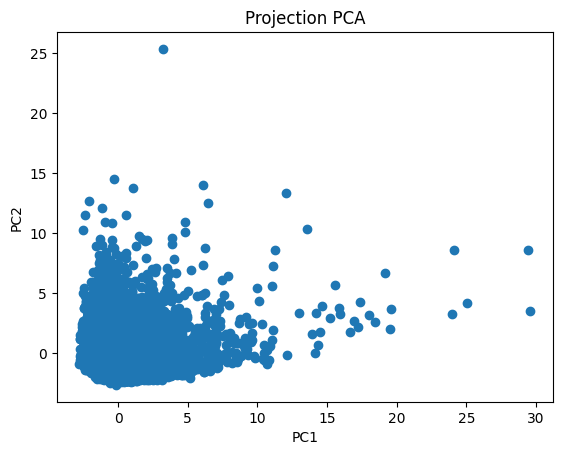

In [44]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Ce graphique montre la structure des données.
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA")
plt.show()

## Explication

```python
X_pca[:,0]
```

Toutes les valeurs de la **première composante**.

```python
X_pca[:,1]
```

Toutes les valeurs de la **deuxième composante**.


# 🔟 CHOISIR LE NOMBRE DE CLUSTERS

### Méthode :

`Elbow Method`


In [45]:
wcss = []

### WCSS

**Définition :**

```
WCSS = Within Cluster Sum of Squares
```

**Mesure :** la compacité des clusters.


In [46]:
# Teste les valeurs : K = 1 → 10
for k in range(1, 11):

    # Crée un modèle
    kmeans = KMeans(n_clusters=k, n_init=10)

    # Apprend les clusters
    kmeans.fit(X_scaled)

    # inertia_ = WCSS
    wcss.append(kmeans.inertia_)

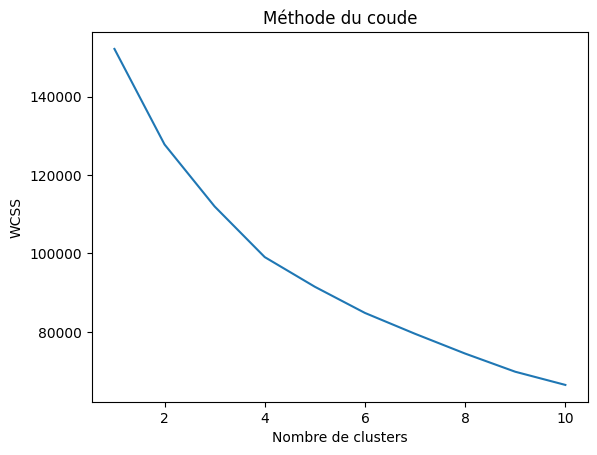

In [47]:
# Graphique

plt.plot(range(1, 11), wcss)
plt.xlabel("Nombre de clusters")
plt.ylabel("WCSS")
plt.title("Méthode du coude")
plt.show()

Le coude du graphique donne le meilleur K.


# 1️⃣1️⃣ CLUSTERING K-MEANS


In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)

# Pourquoi random_state=42 ?

# Pour que les résultats soient reproductibles.

In [49]:
clusters = kmeans.fit_predict(X_scaled)

### Deux actions

#### `fit()`

Apprentissage du modèle.

#### `predict()`

Assigner chaque client à un cluster.


In [50]:
# On ajoute la colonne cluster.
df["Cluster"] = clusters

# 1️⃣2️⃣ VISUALISATION DES CLUSTERS


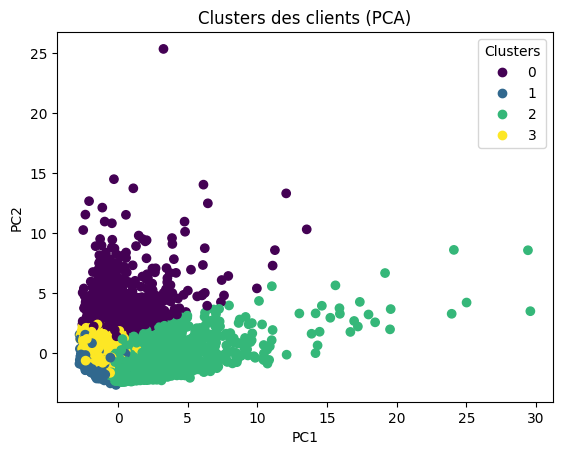

In [ ]:
# On stocke le scatter dans une variable 'scatter'
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.title("Clusters des clients (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Utilisation automatique des couleurs du graphique pour la légende
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

# 1️⃣3️⃣ VISUALISATION t-SNE

### Méthode :

`t-SNE`

Avantage :

préserve la structure locale des données.


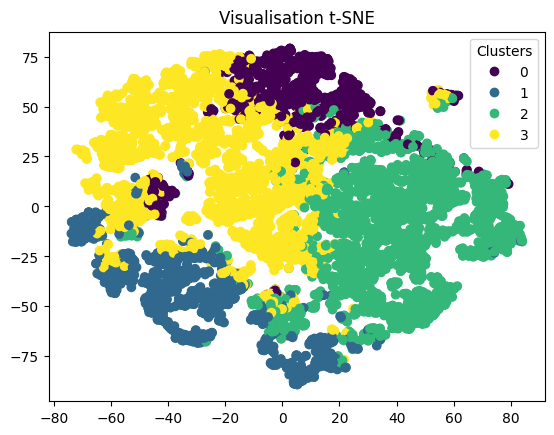

In [ ]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_scaled)

# On stocke le scatter dans une variable 'scatter'
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters)

plt.title("Visualisation t-SNE")

# Utilisation automatique des couleurs du graphique pour la légende
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

# 1️⃣4️⃣ ANALYSE DES CLUSTERS


In [53]:
df.groupby("Cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5010.394668,0.966663,716.017789,450.235875,265.885977,5065.974690,0.327150,0.160632,0.218675,0.508502,15.770727,10.345957,8208.653578,4173.817878,2214.536286,0.040025,11.416581
1,108.430006,0.412096,350.247868,190.521089,160.197189,299.482324,0.320591,0.072760,0.234912,0.035072,0.730330,4.812374,3632.112008,1036.853064,172.183554,0.253704,11.217888
2,1253.817942,0.974758,2182.022178,1241.768493,940.517248,234.564524,0.928413,0.390217,0.748106,0.041717,0.807569,32.727389,5121.987288,2148.583305,778.937414,0.282970,11.729314
3,1495.324927,0.966467,283.482824,210.004454,73.794186,782.285268,0.207097,0.098032,0.108717,0.157514,2.988420,3.665380,3216.349960,947.961448,805.685810,0.022886,11.482482


Cela calcule la moyenne des variables par cluster.


### Ce que fait `groupby`

Il regroupe les clients par cluster.

### Exemple simplifié

**Cluster 0 :**

- Client 1 : balance = 500
- Client 2 : balance = 700
- **Moyenne = 600**

### Résultat final :

| Cluster | BALANCE | PURCHASES | CREDIT_LIMIT |
| ------- | ------- | --------- | ------------ |
| 0       | 600     | 1500      | 3000         |
| 1       | 2000    | 5000      | 8000         |

## Pourquoi c'est essentiel ?

K-Means ne donne que des **numéros** de cluster (0, 1, 2, 3...).

**`groupby.mean()`** permet de comprendre :  
👉 **Le profil moyen de chaque cluster**


In [54]:
# combien de clients dans chaque cluster.
df["Cluster"].value_counts()

Cluster
3    3368
2    3118
1    1487
0     977
Name: count, dtype: int64

### On simplifie les variables les plus importantes :

| Cluster | Balance | Purchases | Cash Advance | Credit Limit | Purchase Frequency |
| ------- | ------- | --------- | ------------ | ------------ | ------------------ |
| 0       | ≈5010   | 716       | 5065         | ≈8200        | 0.33               |
| 1       | ≈108    | 350       | 299          | ≈3632        | 0.32               |
| 2       | ≈1253   | 2182      | 234          | ≈5122        | 0.93               |
| 3       | ≈1495   | 283       | 782          | ≈3216        | 0.21               |

---

### Nommer les clusters

#### Cluster 0 — Cash Advance Heavy Users

**Caractéristiques :**

- balance très élevée
- cash advance très élevé (~5065)
- limite de crédit élevée

**Comportement :**  
➡️ Clients qui utilisent fréquemment le **cash advance**, ce qui indique une forte dépendance au crédit.

**Risques :**

- dette élevée
- risque de défaut de paiement

**Décision business :**

- surveiller le risque de crédit
- ajuster les limites de crédit
- proposer des solutions de gestion de dette

---

#### Cluster 1 — Responsible Low-Balance Users

**Caractéristiques :**

- balance très faible (~108)
- achats modérés
- cash advance faible
- limite de crédit moyenne

**Comportement :**  
➡️ Clients qui utilisent la carte mais **remboursent rapidement leurs dépenses**, ce qui maintient une balance très faible.

**Décision business :**

**Objectif :** augmenter l'utilisation de la carte.

**Actions :**

- programmes cashback
- promotions et réductions
- programmes de fidélité pour encourager plus de transactions

---

#### Cluster 2 — High Spenders / Active Card Users

**Caractéristiques :**

- achats très élevés (~2182)
- fréquence d'achat très élevée (**0.93**)
- paiements élevés
- utilisation très active de la carte

**Comportement :**  
➡️ Clients très actifs qui utilisent régulièrement leur carte pour effectuer des achats.

**Ce sont les clients les plus rentables pour la banque.**

**Décision business :**

**Fidéliser ces clients :**

- offres premium
- cartes haut de gamme
- programmes VIP
- avantages exclusifs

---

#### Cluster 3 — Occasional Users

**Caractéristiques :**

- achats relativement faibles
- cash advance modéré
- faible fréquence d'achat (**0.21**)

**Comportement :**  
➡️ Clients qui utilisent leur carte **de manière occasionnelle et irrégulière**.

**Décision business :**

- campagnes marketing ciblées
- incitations à utiliser plus souvent la carte
- offres promotionnelles personnalisées

---

### Résumé des segments

| Cluster | Nom                           |
| ------- | ----------------------------- |
| 0       | Cash Advance Heavy Users      |
| 1       | Responsible Low-Balance Users |
| 2       | High Spenders                 |
| 3       | Occasional Users              |

---

### Business insights

#### Insight 1

**Les clients du Cluster 2 sont les plus rentables.**

**Stratégie :**

- fidélisation
- offres premium
- upgrade vers des cartes haut de gamme

---

#### Insight 2

**Le Cluster 0 utilise fortement le cash advance.**

**Problème :**  
Une utilisation élevée du cash advance peut indiquer une dépendance au crédit et un risque financier plus important.

**Stratégie :**

- gestion du risque
- surveillance du crédit
- ajustement des limites

---

#### Insight 3

**Le Cluster 1 maintient une balance très faible.**

Ces clients remboursent rapidement leurs dépenses.

**Potentiel marketing :**

- encourager plus de transactions
- programmes de récompenses

---

### Takeaways stratégiques

1️⃣ **Les clients présentent des comportements financiers très différents.**

2️⃣ **La segmentation permet de cibler les stratégies marketing et de gestion du risque.**

3️⃣ **Certains segments génèrent plus de revenus (clients très actifs).**

4️⃣ **D'autres segments nécessitent une surveillance ou des stratégies d'engagement spécifiques.**
